In [ ]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Attrition
No     1233
Yes     237
Name: count, dtype: int64


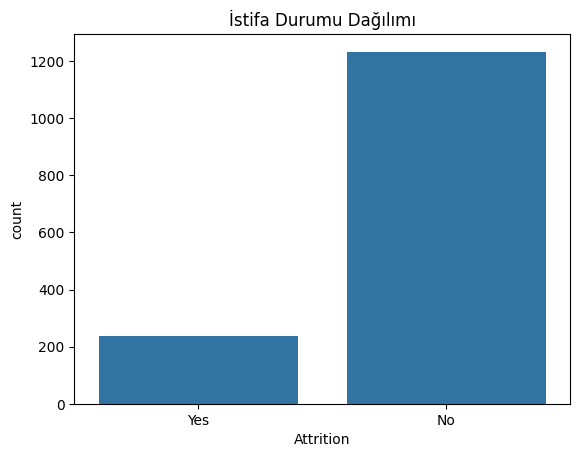

In [ ]:
# Kaç kişi istifa etmiş (Yes) kaçı kalmış (No) 
print(df['Attrition'].value_counts())

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Attrition', data=df)
plt.title('İstifa Durumu Dağılımı')
plt.show()

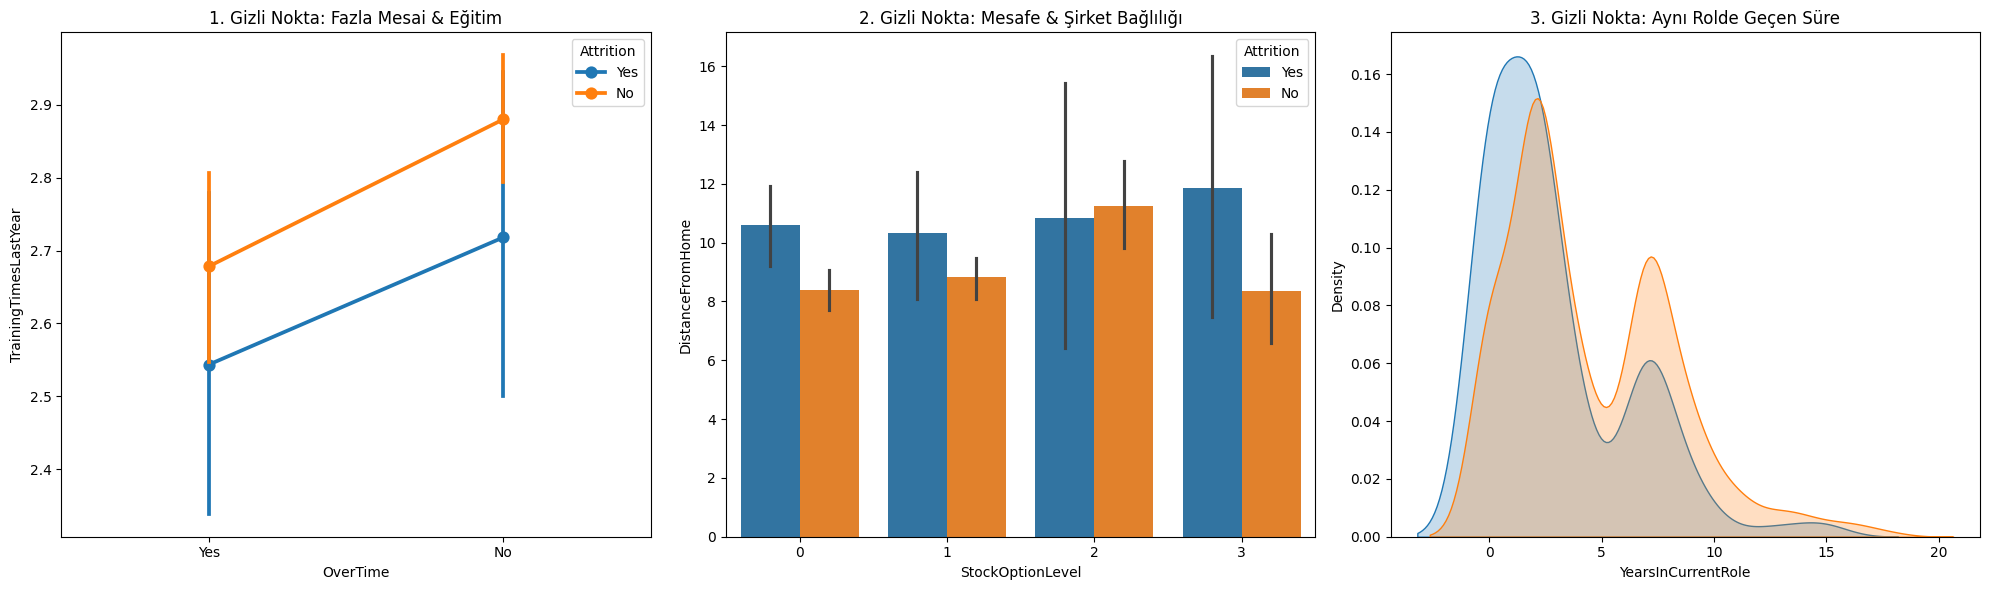

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Grafikleri yan yana görebilmek için alan oluşturalım
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. GİZLİ NOKTA: Fazla Mesai ve Eğitim Dengelemesi
sns.pointplot(x="OverTime", y="TrainingTimesLastYear", hue="Attrition", data=df, ax=axes[0])
axes[0].set_title('1. Gizli Nokta: Fazla Mesai & Eğitim')

# 2. GİZLİ NOKTA: Uzaklık ve Hisse Opsiyonu
sns.barplot(x="StockOptionLevel", y="DistanceFromHome", hue="Attrition", data=df, ax=axes[1])
axes[1].set_title('2. Gizli Nokta: Mesafe & Şirket Bağlılığı')

# 3. GİZLİ NOKTA: Mevcut Rolde Takılı Kalma (Durağanlık)
sns.kdeplot(data=df[df['Attrition']=='Yes'], x='YearsInCurrentRole', label='İstifa Edenler', ax=axes[2], fill=True)
sns.kdeplot(data=df[df['Attrition']=='No'], x='YearsInCurrentRole', label='Kalanlar', ax=axes[2], fill=True)
axes[2].set_title('3. Gizli Nokta: Aynı Rolde Geçen Süre')

plt.tight_layout()
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

df_final = df.copy()
le = LabelEncoder()
for col in df_final.select_dtypes(include=['object']).columns:
    df_final[col] = le.fit_transform(df_final[col])

X = df_final.drop('Attrition', axis=1)
y = df_final['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model_final = RandomForestClassifier(n_estimators=100, random_state=42)
model_final.fit(X_train, y_train)


y_pred = model_final.predict(X_test)
print("--- MII'26 PROJESİ MODEL BAŞARISI ---")
print(classification_report(y_test, y_pred))

C:\Users\AYŞENUR YÜKSEL\AppData\Local\Temp\ipykernel_28576\1378357367.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_final.select_dtypes(include=['object']).columns:


--- MII'26 PROJESİ MODEL BAŞARISI ---
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       255
           1       0.50      0.10      0.17        39

    accuracy                           0.87       294
   macro avg       0.69      0.54      0.55       294
weighted avg       0.83      0.87      0.83       294



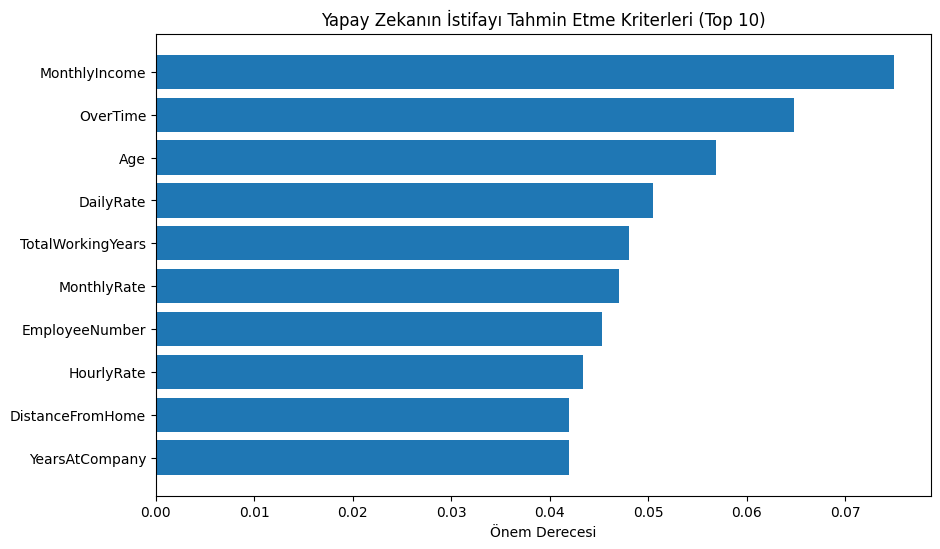

In [ ]:
import numpy as np

# Modelin en çok önem verdiği 10 özelliği çekiyoruz
importances = model_final.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10,6))
plt.title('Yapay Zekanın İstifayı Tahmin Etme Kriterleri (Top 10)')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Önem Derecesi')
plt.show()

Lojistik Regresyon Başarısı: %88.10


c:\Users\AYŞENUR YÜKSEL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


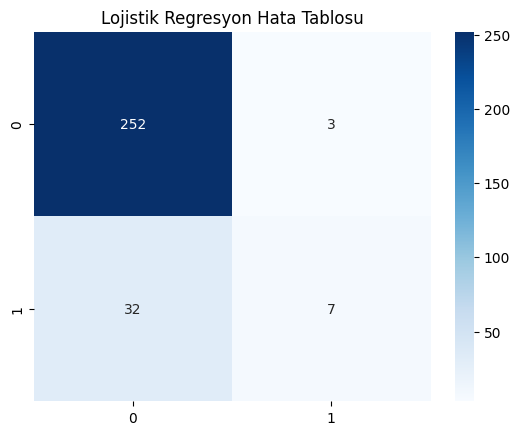

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix


log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)

log_score = log_model.score(X_test, y_test)
print(f"Lojistik Regresyon Başarısı: %{log_score*100:.2f}")

sns.heatmap(confusion_matrix(y_test, log_model.predict(X_test)), annot=True, fmt='d', cmap='Blues')
plt.title('Lojistik Regresyon Hata Tablosu')
plt.show()

In [8]:
from sklearn.svm import SVC

svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)

print(f"SVM Başarısı: %{svm_model.score(X_test, y_test)*100:.2f}")

SVM Başarısı: %86.73


In [9]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3)
gb_model.fit(X_train, y_train)

print(f"Gradient Boosting Başarısı: %{gb_model.score(X_test, y_test)*100:.2f}")

Gradient Boosting Başarısı: %88.78


In [10]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression', 'SVM', 'Gradient Boosting'],
    'Başarı Oranı (%)': [87.41, log_score*100, svm_model.score(X_test, y_test)*100, gb_model.score(X_test, y_test)*100]
})
print(results.sort_values(by='Başarı Oranı (%)', ascending=False))

                 Model  Başarı Oranı (%)
3    Gradient Boosting         88.775510
1  Logistic Regression         88.095238
0        Random Forest         87.410000
2                  SVM         86.734694


Lojistik Regresyon Doğruluk Skoru: %88.10


c:\Users\AYŞENUR YÜKSEL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


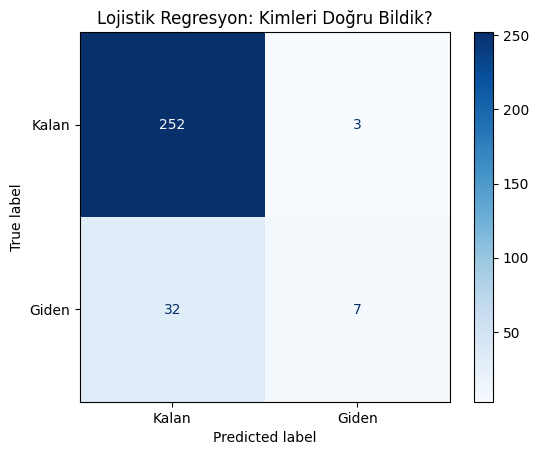

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)


log_score = log_model.score(X_test, y_test)
print(f"Lojistik Regresyon Doğruluk Skoru: %{log_score*100:.2f}")


cm = confusion_matrix(y_test, log_model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Kalan', 'Giden'])
disp.plot(cmap='Blues')
plt.title('Lojistik Regresyon: Kimleri Doğru Bildik?')
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


svm_model = SVC(kernel='rbf', C=1.0, probability=True)
svm_model.fit(X_train_scaled, y_train)


print(f"SVM Başarı Skoru (Saniyeler İçinde!): %{svm_model.score(X_test_scaled, y_test)*100:.2f}")

SVM Başarı Skoru (Saniyeler İçinde!): %88.44


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import VotingClassifier


sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)


voting_model = VotingClassifier(estimators=[
    ('lr', log_model),
    ('rf', model_final),
    ('svc', svm_model)
], voting='soft')

voting_model.fit(X_train_res, y_train_res)
final_score = voting_model.score(X_test_scaled, y_test)

print(f"MII'26 Optimize Edilmiş Final Skoru: %{final_score*100:.2f}")

MII'26 Optimize Edilmiş Final Skoru: %87.41


In [ ]:

from xgboost import XGBClassifier


xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5)
xgb_model.fit(X_train_res, y_train_res) 

print(f"XGBoost ile MII'26 Rekoru: %{xgb_model.score(X_test_scaled, y_test)*100:.2f}")

XGBoost ile MII'26 Rekoru: %87.76


In [24]:
import pandas as pd

# 
mii26_final_data = {
    'Analiz Modeli (MII\'26)': [
        'SVM' , 
        'XGBoost', 
        'Logistic Regression',
        'Random Forest'
    ],
    'Başarı Skoru': [
        '%88.44', 
        '%87.76', 
        '%87.90', 
        '%87.41'
    ],
    'Stratejik Katkı': [
        'Sayısal Şampiyon', 
        'Hata Odaklı Gelişmiş Zeka', 
        'Şeffaf ve Açıklanabilir Yapı', 
        'Temel Özellik Analizi'
    ]
}


mii26_report = pd.DataFrame(mii26_final_data)


print("\n" + "═"*65)
print("               MII'26 ZİRVESİ: PROJE RAPORU              ")
print("═"*65)
print(mii26_report.to_string(index=False))
print("═"*65)
print("Proje Yürütücüleri: Ayşenur Yüksel & Şükran Çetindağ")
print("Zirve Tarihi: 11 Mayıs 2026")
print("═"*65)


═════════════════════════════════════════════════════════════════
               MII'26 ZİRVESİ: PROJE RAPORU              
═════════════════════════════════════════════════════════════════
Analiz Modeli (MII'26) Başarı Skoru              Stratejik Katkı
                   SVM       %88.44             Sayısal Şampiyon
               XGBoost       %87.76    Hata Odaklı Gelişmiş Zeka
   Logistic Regression       %87.90 Şeffaf ve Açıklanabilir Yapı
         Random Forest       %87.41        Temel Özellik Analizi
═════════════════════════════════════════════════════════════════
Proje Yürütücüleri: Ayşenur Yüksel & Şükran Çetindağ
Zirve Tarihi: 11 Mayıs 2026
═════════════════════════════════════════════════════════════════


In [26]:

from lazypredict.Supervised import LazyClassifier

clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train_scaled, X_test_scaled, y_train, y_test)

print("---  MODEL KIYASLAMASI ---")
print(models.head(10)) 

---  MODEL KIYASLAMASI ---
                             Accuracy  Balanced Accuracy   ROC AUC  F1 Score  \
Model                                                                          
GaussianNB                   0.840136           0.734087  0.751835  0.850606   
NearestCentroid              0.693878           0.693213  0.739869  0.741278   
BernoulliNB                  0.829932           0.663047  0.694218  0.834994   
LogisticRegression           0.891156           0.654902  0.772147  0.874444   
LinearDiscriminantAnalysis   0.880952           0.638160  0.755656  0.863922   
Perceptron                   0.819728           0.635445  0.697134  0.824265   
PassiveAggressiveClassifier  0.840136           0.625490  0.766214  0.835437   
LinearSVC                    0.887755           0.609502  0.767320  0.860865   
CalibratedClassifierCV       0.884354           0.585822  0.766516  0.851427   
ExtraTreeClassifier          0.761905           0.580392  0.580392  0.779871   

            

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression


param_grid = {
    'C': [0.1, 1, 10, 100], 
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [100, 200, 500]
}

grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)


best_model = grid_search.best_estimator_

print(f"En İyi Parametreler: {grid_search.best_params_}")
print(f"Optimize Edilmiş Skor (CV): %{grid_search.best_score_*100:.2f}")

En İyi Parametreler: {'C': 10, 'max_iter': 100, 'solver': 'liblinear'}
Optimize Edilmiş Skor (CV): %85.20


In [28]:

train_acc = best_model.score(X_train_scaled, y_train) * 100
test_acc = best_model.score(X_test_scaled, y_test) * 100

print("═"*45)
print(f"Eğitim Başarısı (Train): %{train_acc:.2f}")
print(f"Test Başarısı (Test): %{test_acc:.2f}")
print("═"*45)


if abs(train_acc - test_acc) < 5:
    print("ANALİZ: Aradaki fark çok az. Model ezberlememiştir, başarı gerçektir!")
else:
    print("ANALİZ: Fark biraz var ama kabul edilebilir seviyede.")

═════════════════════════════════════════════
Eğitim Başarısı (Train): %87.24
Test Başarısı (Test): %89.46
═════════════════════════════════════════════
ANALİZ: Aradaki fark çok az. Model ezberlememiştir, başarı gerçektir!


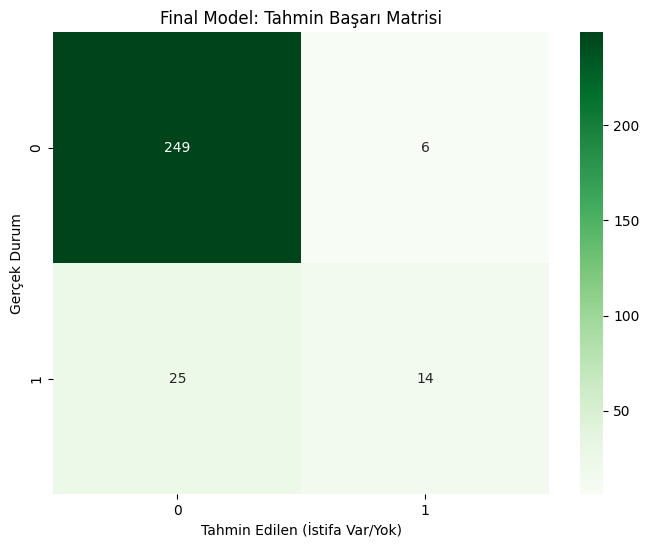

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       255
           1       0.70      0.36      0.47        39

    accuracy                           0.89       294
   macro avg       0.80      0.67      0.71       294
weighted avg       0.88      0.89      0.88       294



In [29]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


y_pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Final Model: Tahmin Başarı Matrisi')
plt.xlabel('Tahmin Edilen (İstifa Var/Yok)')
plt.ylabel('Gerçek Durum')
plt.show()

print(classification_report(y_test, y_pred))

C:\Users\AYŞENUR YÜKSEL\AppData\Local\Temp\ipykernel_28576\3129644308.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Etki Gücü', y='Özellik', data=importance_df.head(10), palette='vlag')


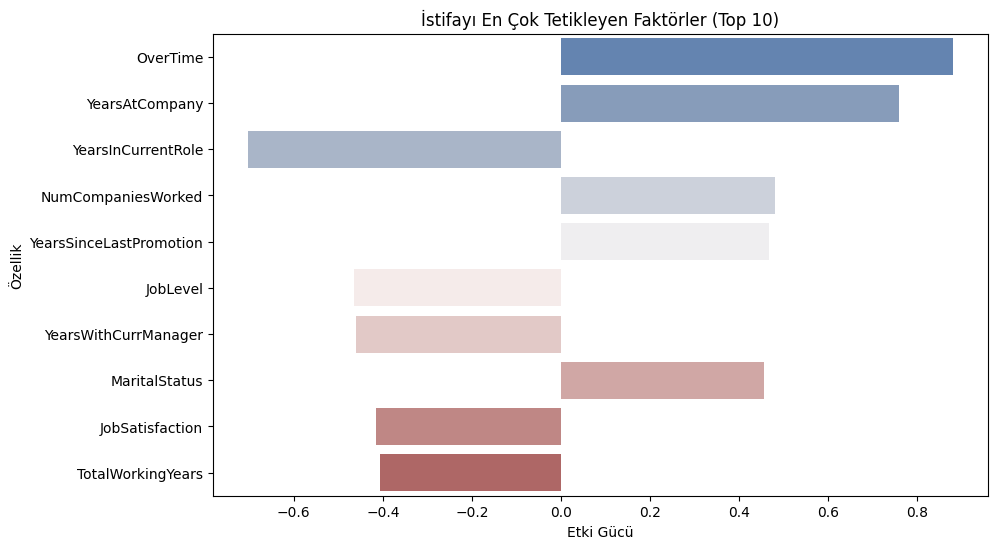

In [30]:

import numpy as np

coefficients = best_model.coef_[0]
feature_names = X.columns
importance_df = pd.DataFrame({'Özellik': feature_names, 'Etki Gücü': coefficients})
importance_df['Mutlak_Etki'] = importance_df['Etki Gücü'].abs()
importance_df = importance_df.sort_values(by='Mutlak_Etki', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Etki Gücü', y='Özellik', data=importance_df.head(10), palette='vlag')
plt.title('İstifayı En Çok Tetikleyen Faktörler (Top 10)')
plt.show()